<a href="https://colab.research.google.com/github/AHIRWE1/linear_regression_model/blob/main/Multivariate.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Student Performance Prediction Using Machine Learning

## Course: AI Deployment

### Objective

The objective of this project is to develop and evaluate regression models capable of predicting students' final examination scores using demographic, academic, and behavioural features. The best-performing model is then prepared for deployment using FastAPI.

# 1. Import Libraries

The required libraries are imported for data manipulation, visualization, preprocessing, model training, evaluation, and model persistence.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import joblib

# 2. Load the Dataset

The dataset is loaded into a Pandas DataFrame for inspection and preprocessing.

In [4]:
df = pd.read_csv("/content/student_performance_dataset.csv")

# 3. Exploratory Data Analysis

Before building the model, the dataset is explored to identify missing values, duplicate records, data types, and statistical characteristics.

In [15]:
print("First Five Rows:")
display(df.head())

First Five Rows:


,student_id,gender,study_time_hours,attendance_percent,sleep_hours,parental_education,internet_access,extracurricular_activities,part_time_job,previous_grade,final_exam_score,final_grade
0,1,Male,4.0,98.0,6.5,Bachelors,Yes,Yes,No,76.9,100.0,A
1,2,Female,6.3,100.0,5.7,High School,Yes,Yes,Yes,75.5,100.0,A
2,3,Male,4.9,85.3,7.9,Bachelors,Yes,No,Yes,88.5,97.3,A
3,4,Male,2.6,77.5,8.0,NaN,Yes,Yes,No,85.1,83.8,B
4,5,Male,2.2,89.6,4.6,Bachelors,Yes,No,Yes,61.8,68.3,D


df.shape

print("Shape of dataset:")
print(df.shape)

In [9]:
print("Dataset Information:")
df.info()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   student_id                  1000 non-null   int64  
 1   gender                      1000 non-null   object 
 2   study_time_hours            1000 non-null   float64
 3   attendance_percent          1000 non-null   float64
 4   sleep_hours                 1000 non-null   float64
 5   parental_education          898 non-null    object 
 6   internet_access             1000 non-null   object 
 7   extracurricular_activities  1000 non-null   object 
 8   part_time_job               1000 non-null   object 
 9   previous_grade              1000 non-null   float64
 10  final_exam_score            1000 non-null   float64
 11  final_grade                 1000 non-null   object 
dtypes: float64(5), int64(1), object(6)
memory usage: 93.9+ KB


In [16]:
print("Statistical Summary:")
display(df.describe())

Statistical Summary:


,student_id,study_time_hours,attendance_percent,sleep_hours,previous_grade,final_exam_score
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,3.570700,85.092300,6.799500,69.740900,83.543500
std,288.819436,1.478559,9.270685,1.203527,12.613425,10.341333
min,1.000000,0.500000,54.800000,3.200000,31.300000,46.800000
25%,250.750000,2.600000,78.800000,5.900000,61.000000,76.075000
50%,500.500000,3.600000,85.200000,6.800000,69.600000,83.800000
75%,750.250000,4.500000,91.900000,7.600000,78.400000,91.525000
max,1000.000000,8.100000,100.000000,10.000000,100.000000,100.000000


In [11]:
# Check missing values
df.isnull().sum()

,0
student_id,0
gender,0
study_time_hours,0
attendance_percent,0
sleep_hours,0
parental_education,102
internet_access,0
extracurricular_activities,0
part_time_job,0
previous_grade,0


In [12]:
# Check for duplicate rows
df.duplicated().sum()

np.int64(0)

In [13]:
# Display all column names
df.columns

Index(['student_id', 'gender', 'study_time_hours', 'attendance_percent',
       'sleep_hours', 'parental_education', 'internet_access',
       'extracurricular_activities', 'part_time_job', 'previous_grade',
       'final_exam_score', 'final_grade'],
      dtype='object')

**Data Cleaning**

The student_id column was removed because it is only an identifier and does not contribute to predicting student performance. The final_grade column was also removed because it is derived from the final_exam_score and would introduce data leakage into the model.

In [18]:
df = df.drop(columns=["student_id", "final_grade"])

In [19]:
df.dtypes

,0
gender,object
study_time_hours,float64
attendance_percent,float64
sleep_hours,float64
parental_education,object
internet_access,object
extracurricular_activities,object
part_time_job,object
previous_grade,float64
final_exam_score,float64


In [20]:
categorical_columns = df.select_dtypes(include=["object"]).columns

for col in categorical_columns:
    print(f"\n{col}")
    print(df[col].value_counts())


gender
gender
Female    510
Male      490
Name: count, dtype: int64

parental_education
parental_education
High School    356
Bachelors      308
Masters        184
PhD             50
Name: count, dtype: int64

internet_access
internet_access
Yes    854
No     146
Name: count, dtype: int64

extracurricular_activities
extracurricular_activities
Yes    572
No     428
Name: count, dtype: int64

part_time_job
part_time_job
No     684
Yes    316
Name: count, dtype: int64


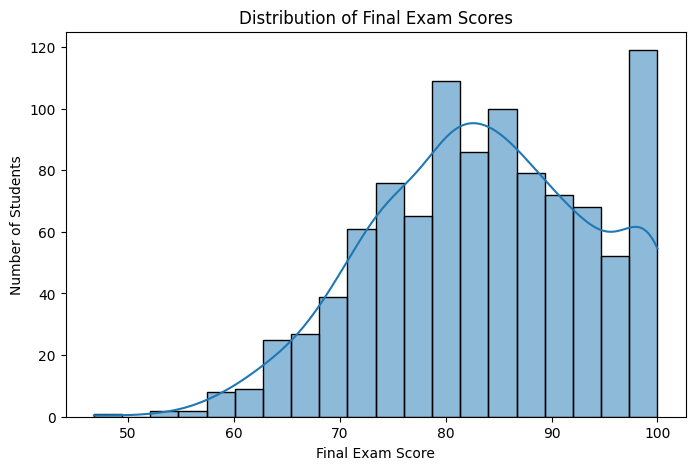

In [21]:
plt.figure(figsize=(8,5))
sns.histplot(df["final_exam_score"], bins=20, kde=True)

plt.title("Distribution of Final Exam Scores")
plt.xlabel("Final Exam Score")
plt.ylabel("Number of Students")

plt.show()

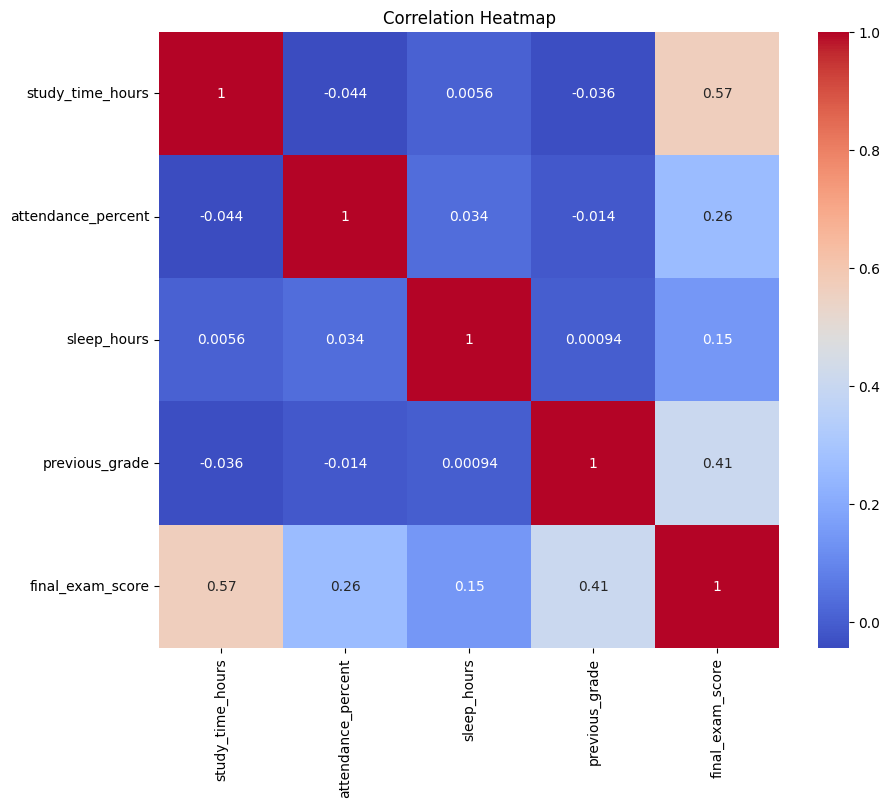

In [22]:
plt.figure(figsize=(10,8))

sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

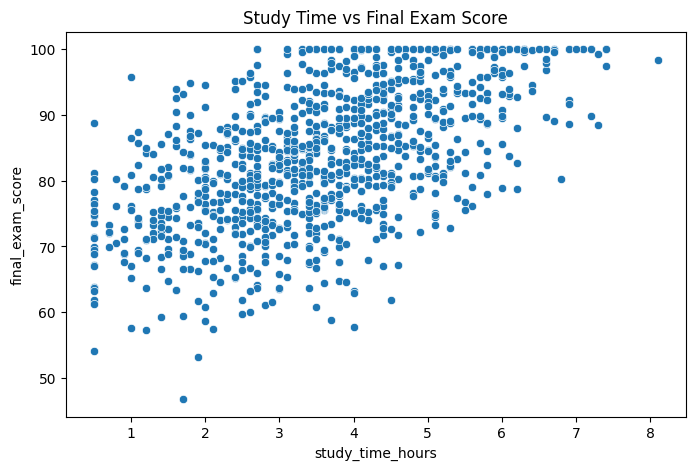

In [23]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="study_time_hours",
    y="final_exam_score"
)

plt.title("Study Time vs Final Exam Score")

plt.show()

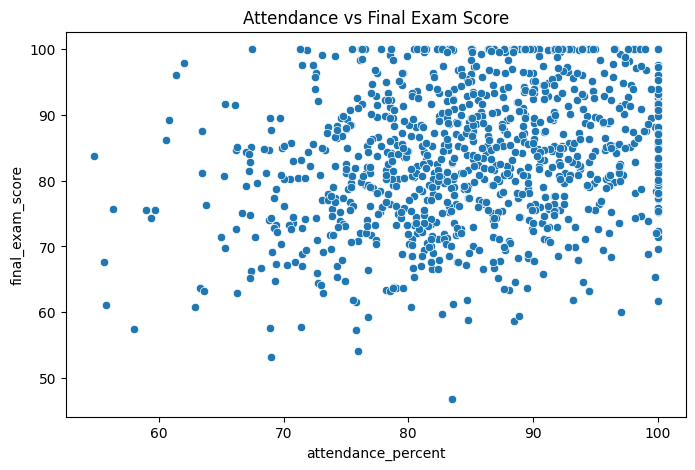

In [24]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="attendance_percent",
    y="final_exam_score"
)

plt.title("Attendance vs Final Exam Score")

plt.show()

In [25]:
# One-Hot Encode categorical variables
df = pd.get_dummies(df, drop_first=True)

# Check the transformed dataset
df.head()

,study_time_hours,attendance_percent,sleep_hours,previous_grade,final_exam_score,gender_Male,parental_education_High School,parental_education_Masters,parental_education_PhD,internet_access_Yes,extracurricular_activities_Yes,part_time_job_Yes
0,4.0,98.0,6.5,76.9,100.0,True,False,False,False,True,True,False
1,6.3,100.0,5.7,75.5,100.0,False,True,False,False,True,True,True
2,4.9,85.3,7.9,88.5,97.3,True,False,False,False,True,False,True
3,2.6,77.5,8.0,85.1,83.8,True,False,False,False,True,True,False
4,2.2,89.6,4.6,61.8,68.3,True,False,False,False,True,False,True


In [26]:
X = df.drop("final_exam_score", axis=1)
y = df["final_exam_score"]

In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [28]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [29]:
# Create the models
linear_model = LinearRegression()

sgd_model = SGDRegressor(
    max_iter=1000,
    learning_rate='constant',
    eta0=0.01,
    random_state=42
)

decision_tree = DecisionTreeRegressor(random_state=42)

random_forest = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

In [30]:
# Linear Regression
linear_model.fit(X_train_scaled, y_train)

# SGD Regressor
sgd_model.fit(X_train_scaled, y_train)

# Decision Tree
decision_tree.fit(X_train, y_train)

# Random Forest
random_forest.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [31]:
linear_pred = linear_model.predict(X_test_scaled)

sgd_pred = sgd_model.predict(X_test_scaled)

tree_pred = decision_tree.predict(X_test)

forest_pred = random_forest.predict(X_test)

In [32]:
import numpy as np

def evaluate_model(name, y_true, predictions):
    mae = mean_absolute_error(y_true, predictions)
    mse = mean_squared_error(y_true, predictions)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, predictions)

    print(f"\n{name}")
    print("-" * 40)
    print(f"MAE : {mae:.2f}")
    print(f"MSE : {mse:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"R²  : {r2:.4f}")

In [35]:
results = pd.DataFrame({
    "Model": ["Linear Regression",
              "SGD Regressor",
              "Decision Tree",
              "Random Forest"],
    "MAE": [
        mean_absolute_error(y_test, linear_pred),
        mean_absolute_error(y_test, sgd_pred),
        mean_absolute_error(y_test, tree_pred),
        mean_absolute_error(y_test, forest_pred)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, linear_pred)),
        np.sqrt(mean_squared_error(y_test, sgd_pred)),
        np.sqrt(mean_squared_error(y_test, tree_pred)),
        np.sqrt(mean_squared_error(y_test, forest_pred))
    ],
    "R2 Score": [
        r2_score(y_test, linear_pred),
        r2_score(y_test, sgd_pred),
        r2_score(y_test, tree_pred),
        r2_score(y_test, forest_pred)
    ]
})

results.sort_values(by="R2 Score", ascending=False)


,Model,MAE,RMSE,R2 Score
1,SGD Regressor,4.995204,6.416524,0.617494
0,Linear Regression,4.989860,6.419254,0.617168
3,Random Forest,5.279860,6.794864,0.571057
2,Decision Tree,6.913000,8.955641,0.254870


In [36]:
import joblib

joblib.dump(sgd_model, "best_model.pkl")
joblib.dump(scaler, "scaler.pkl")

print("Model and scaler saved successfully!")

Model and scaler saved successfully!


In [37]:
loaded_model = joblib.load("best_model.pkl")
loaded_scaler = joblib.load("scaler.pkl")

In [38]:
sample = X_test.iloc[[0]]

sample_scaled = loaded_scaler.transform(sample)

prediction = loaded_model.predict(sample_scaled)

print("Predicted Score:", prediction[0])
print("Actual Score:", y_test.iloc[0])

Predicted Score: 79.96918118995458
Actual Score: 71.8


In [39]:
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

train_loss = []
test_loss = []

sgd_loss_model = SGDRegressor(
    max_iter=1,
    warm_start=True,
    learning_rate="constant",
    eta0=0.01,
    random_state=42
)

epochs = 100

for epoch in range(epochs):
    sgd_loss_model.fit(X_train_scaled, y_train)

    train_pred = sgd_loss_model.predict(X_train_scaled)
    test_pred = sgd_loss_model.predict(X_test_scaled)

    train_loss.append(mean_squared_error(y_train, train_pred))
    test_loss.append(mean_squared_error(y_test, test_pred))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:1608: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:1608: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:1608: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:1608: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stocha

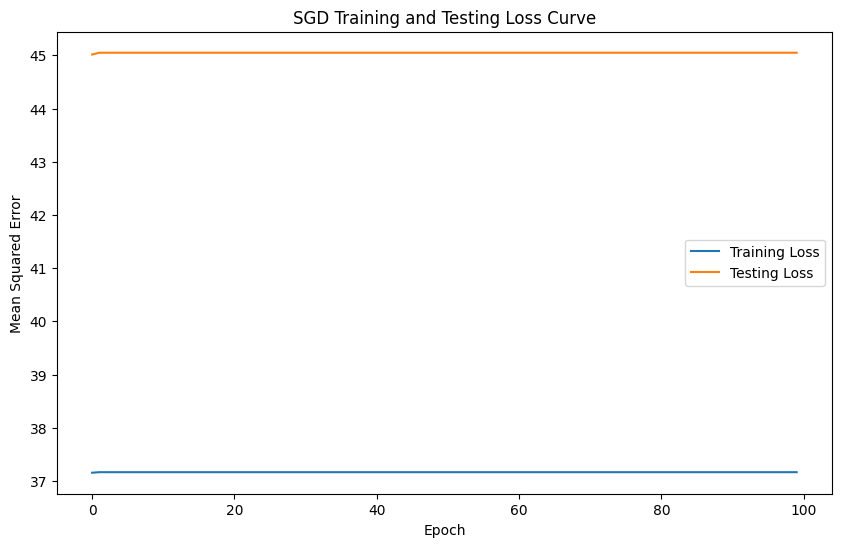

In [40]:
plt.figure(figsize=(10,6))

plt.plot(train_loss, label="Training Loss")
plt.plot(test_loss, label="Testing Loss")

plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error")
plt.title("SGD Training and Testing Loss Curve")

plt.legend()

plt.show()

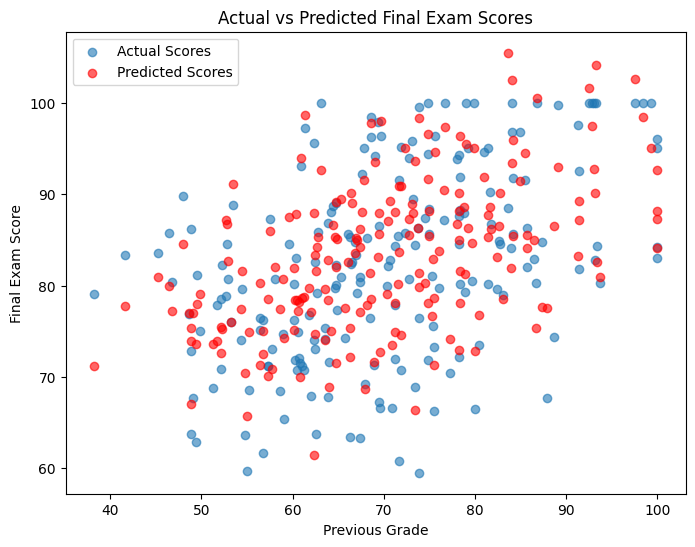

In [41]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_test["previous_grade"],
    y_test,
    alpha=0.6,
    label="Actual Scores"
)

plt.scatter(
    X_test["previous_grade"],
    linear_pred,
    color="red",
    alpha=0.6,
    label="Predicted Scores"
)

plt.xlabel("Previous Grade")
plt.ylabel("Final Exam Score")
plt.title("Actual vs Predicted Final Exam Scores")

plt.legend()

plt.show()

The red points represent the model's predicted exam scores, while the blue points are the actual exam scores. The closer the predicted points are to the actual points, the more accurate the model. Although there is some variation, the predictions generally follow the same trend as the actual scores, indicating that the model captures the relationship reasonably well.

In [42]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "SGD Regressor",
        "Decision Tree",
        "Random Forest"
    ],
    "MAE": [4.99, 5.00, 6.91, 5.28],
    "RMSE": [6.42, 6.42, 8.96, 6.79],
    "R2 Score": [0.6172, 0.6175, 0.2549, 0.5711]
})

results.sort_values(by="R2 Score", ascending=False)

,Model,MAE,RMSE,R2 Score
1,SGD Regressor,5.00,6.42,0.6175
0,Linear Regression,4.99,6.42,0.6172
3,Random Forest,5.28,6.79,0.5711
2,Decision Tree,6.91,8.96,0.2549


Conclusion

Four regression algorithms were developed and evaluated to predict students' final examination scores using demographic, academic, and lifestyle features. The models were assessed using Mean Absolute Error (MAE), Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and the R² score. Among the evaluated models, the SGD Regressor achieved the highest R² score (0.6175), indicating that it explained approximately 61.75% of the variance in the target variable while maintaining one of the lowest prediction errors. Consequently, the SGD Regressor was selected as the final model and saved for deployment in the FastAPI application.